In [2]:
# load packages
import os
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback, EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

/home/ashc/miniforge3/envs/thesis-rl/lib/python3.10/site-packages/gym/envs/registration.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
while not os.getcwd().endswith("GGSpeciale"):
    os.chdir("..")
os.chdir("code/SPID_code/")
from PySRWrapper import PySRPolicy

while not os.getcwd().endswith("GGSpeciale"):
    os.chdir("..")
os.chdir("simglucose_singlepatient/")
from evaluate import evaluate_insulin_policy
from train_closed import make_env_fn

os.getcwd()

/home/ashc/miniforge3/envs/thesis-rl/lib/python3.10/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


'/faststorage/project/GGSpeciale/GGSpeciale/simglucose_singlepatient'

# Notebook to collect and analyse distilled Symbolic Policies 

## Comparison of policies across Patients
* Generate table of policies 
* Option to sample observations and plot actions
    * (Maybe also for teacher model for comparison) 


Assuming folder structure: 
```
\folder
│
└───adult-001
│   │   best_student_policy.joblib
│   │   ...
│   └───distilled_eval
│   
└───adult-002
│   │   best_student_policy.joblib
│   │   ...
│   └───distilled_eval
| 
```

In [3]:
folder_path = Path("/home/ashc/GGSpeciale/GGSpeciale/simglucose_singlepatient/distil_closed_safe_diagnostic_positive_remapped/positive")
model_name = "best_student_policy.joblib"

policies = []

for folder in folder_path.iterdir():

    if folder.is_dir():        
        file_path = folder / model_name

        if file_path.exists():
            patient_policy = {"patient" : folder.name}
            print(f"loading {folder.name}")

            model = PySRPolicy.load(file_path)

            best = model.policy_list[0].sr.get_best()
            patient_policy["latex"] = model.policy_list[0].sr.latex()
            patient_policy["policy"] = best["equation"]
            patient_policy["complexity"] = int(best["complexity"])
            patient_policy["loss"] = float(best["loss"])
            patient_policy["lambda_format"] = best["lambda_format"]
            patient_policy["model"] = model.policy_list[0]

            policies.append(patient_policy)

loading adult-003
loading adult-009
loading adult-010
loading adult-006
loading adult-001
loading adult-005
loading adult-008
loading adult-002


In [4]:
type(policies)

list

In [5]:
policy_df = pd.DataFrame(policies).sort_values(by="patient").set_index("patient")
policy_df.head()

,latex,policy,complexity,loss,lambda_format,model
patient,,,,,,
adult-001,\left(0.227 + \frac{x_{1} \left(\begin{cases} ...,"square(((greater(0.046080858, x1) * x1) / x0) ...",10,0.273685,PySRFunction(X=>(0.22743656 + x1*Piecewise((1....,<PySRWrapper.PySRWrapper object at 0x7ff49a4bd...
adult-002,\frac{\begin{cases} 1.00 & \text{for}\: \opera...,"greater(-0.48887038, (x0 - (x1 * 0.45089048)) ...",15,0.172243,PySRFunction(X=>3.29556896910714*Piecewise((1....,<PySRWrapper.PySRWrapper object at 0x7ff49a690...
adult-003,\begin{cases} 1.00 & \text{for}\: x_{0} > x_{1...,"less(0.690175 + x1, x0)",5,0.101160,"PySRFunction(X=>Piecewise((1.0, x0 > x1 + 0.69...",<PySRWrapper.PySRWrapper object at 0x7ff49b9bf...
adult-005,407. \left(x_{0} - x_{1}\right)^{8},square(square(square(x0 - x1) * 4.492642)),8,0.325834,PySRFunction(X=>407.387079862317*(x0 - x1)**8),<PySRWrapper.PySRWrapper object at 0x7ff49a692...
adult-006,\begin{cases} 1.00 & \text{for}\: x_{1} + 0.72...,"less(x1 + 0.7272219, sqrt(x0))",6,0.382218,"PySRFunction(X=>Piecewise((1.0, x1 + 0.7272219...",<PySRWrapper.PySRWrapper object at 0x7ff49a4f2...


In [6]:
policies[0]["lambda_format"]

PySRFunction(X=>Piecewise((1.0, x0 > x1 + 0.690175), (0.0, True)))

In [7]:
policy_df

,latex,policy,complexity,loss,lambda_format,model
patient,,,,,,
adult-001,\left(0.227 + \frac{x_{1} \left(\begin{cases} ...,"square(((greater(0.046080858, x1) * x1) / x0) ...",10,0.273685,PySRFunction(X=>(0.22743656 + x1*Piecewise((1....,<PySRWrapper.PySRWrapper object at 0x7ff49a4bd...
adult-002,\frac{\begin{cases} 1.00 & \text{for}\: \opera...,"greater(-0.48887038, (x0 - (x1 * 0.45089048)) ...",15,0.172243,PySRFunction(X=>3.29556896910714*Piecewise((1....,<PySRWrapper.PySRWrapper object at 0x7ff49a690...
adult-003,\begin{cases} 1.00 & \text{for}\: x_{0} > x_{1...,"less(0.690175 + x1, x0)",5,0.101160,"PySRFunction(X=>Piecewise((1.0, x0 > x1 + 0.69...",<PySRWrapper.PySRWrapper object at 0x7ff49b9bf...
adult-005,407. \left(x_{0} - x_{1}\right)^{8},square(square(square(x0 - x1) * 4.492642)),8,0.325834,PySRFunction(X=>407.387079862317*(x0 - x1)**8),<PySRWrapper.PySRWrapper object at 0x7ff49a692...
adult-006,\begin{cases} 1.00 & \text{for}\: x_{1} + 0.72...,"less(x1 + 0.7272219, sqrt(x0))",6,0.382218,"PySRFunction(X=>Piecewise((1.0, x1 + 0.7272219...",<PySRWrapper.PySRWrapper object at 0x7ff49a4f2...
adult-008,\begin{cases} 1.00 & \text{for}\: x_{0} > x_{1...,"greater(x0, x1 + 0.43982384)",5,0.545164,"PySRFunction(X=>Piecewise((1.0, x0 > x1 + 0.43...",<PySRWrapper.PySRWrapper object at 0x7ff49a6d9...
adult-009,\left(- x_{0} + x_{1}\right)^{2},square(x1 - x0),4,0.181165,PySRFunction(X=>(-x0 + x1)**2),<PySRWrapper.PySRWrapper object at 0x7ff49a69d...
adult-010,\left(x_{0} - x_{1}\right)^{2},square(x0 - x1),4,0.362939,PySRFunction(X=>(x0 - x1)**2),<PySRWrapper.PySRWrapper object at 0x7ff49a663...


In [8]:
display_df = policy_df[["latex", "complexity", "loss"]].copy().reset_index()
display_df.columns = ["Patient", "Policy", "Complexity", "Loss"]

# Wrap equations in math mode
display_df["Policy"] = display_df["Policy"].apply(lambda x: f"${x}$")

# Convert to LaTeX table
latex_table = display_df.to_latex(
    index=False,
    escape=False,   # important: keeps LaTeX commands like \frac, \alpha, etc.
)

print(latex_table)

\begin{tabular}{llrr}
\toprule
Patient & Policy & Complexity & Loss \\
\midrule
adult-001 & $\left(0.227 + \frac{x_{1} \left(\begin{cases} 1.00 & \text{for}\: x_{1} < 0.0461 \\0.0 & \text{otherwise} \end{cases}\right)}{x_{0}}\right)^{2}$ & 10 & 0.273685 \\
adult-002 & $\frac{\begin{cases} 1.00 & \text{for}\: \operatorname{ITE}\left(x_{0} - x_{1} > 0.489, - x_{0} + 0.451 x_{1} + 1.00 > 0.489, x_{0} - 0.451 x_{1} < -0.489\right) \\0.0 & \text{otherwise} \end{cases}}{0.303}$ & 15 & 0.172243 \\
adult-003 & $\begin{cases} 1.00 & \text{for}\: x_{0} > x_{1} + 0.690 \\0.0 & \text{otherwise} \end{cases}$ & 5 & 0.101160 \\
adult-005 & $407. \left(x_{0} - x_{1}\right)^{8}$ & 8 & 0.325834 \\
adult-006 & $\begin{cases} 1.00 & \text{for}\: x_{1} + 0.727 < \sqrt{x_{0}} \\0.0 & \text{otherwise} \end{cases}$ & 6 & 0.382218 \\
adult-008 & $\begin{cases} 1.00 & \text{for}\: x_{0} > x_{1} + 0.440 \\0.0 & \text{otherwise} \end{cases}$ & 5 & 0.545164 \\
adult-009 & $\left(- x_{0} + x_{1}\right)^{2}$ & 4 & 0

## Plot Action Space

In [9]:


def plot_pysr_2d(
    pysr_model,
    x0_range,
    x1_range,
    resolution=300,
    fixed_values=None,
    title="PySR policy output",
    clip_output=None,
):
    """
    Plot 2D output surface of a PySRRegressor / PySRFunction.

    Parameters
    ----------
    pysr_model:
        A fitted PySRRegressor or callable PySR function.
    x0_range:
        Tuple (min, max) for x0.
    x1_range:
        Tuple (min, max) for x1.
    resolution:
        Number of grid points per axis.
    fixed_values:
        Optional dict for extra variables if the PySR model expects more than x0/x1.
        Example: {2: 0.0, 3: 0.0}
    title:
        Plot title.
    clip_output:
        Optional tuple (low, high) to clip extreme outputs.
    """

    fixed_values = fixed_values or {}

    x0 = np.linspace(x0_range[0], x0_range[1], resolution)
    x1 = np.linspace(x1_range[0], x1_range[1], resolution)

    X0, X1 = np.meshgrid(x0, x1)

    # Base input: x0 and x1
    X = np.column_stack([
        X0.ravel(),
        X1.ravel()
    ])

    # Add extra fixed variables if needed
    if fixed_values:
        max_idx = max(fixed_values.keys())
        n_features = max(max_idx + 1, 2)

        X_full = np.zeros((X.shape[0], n_features))
        X_full[:, 0] = X[:, 0]
        X_full[:, 1] = X[:, 1]

        for idx, value in fixed_values.items():
            X_full[:, idx] = value

        X = X_full

    # Evaluate PySR model
    if hasattr(pysr_model, "predict"):
        Z = pysr_model.predict(X)
    else:
        Z = pysr_model(X)

    Z = np.asarray(Z, dtype=float).reshape(X0.shape)

    # Transform output before plotting
    Z = 5 * np.exp(4.0 * (Z - 1))

    # Optional clipping, useful if expression explodes
    if clip_output is not None:
        Z = np.clip(Z, clip_output[0], clip_output[1])

    # Detect invalid regions
    invalid_mask = ~np.isfinite(Z)
    if invalid_mask.any():
        print(f"Warning: {invalid_mask.sum()} / {Z.size} grid values are NaN or inf.")
        Z = np.ma.masked_invalid(Z)

    plt.figure(figsize=(8, 6))
    im = plt.imshow(
        Z,
        extent=[x0_range[0]*400, x0_range[1]*400, x1_range[0]*10, x1_range[1]*10],
        origin="lower",
        aspect="auto",
    )
    plt.colorbar(im, label="Insulin dosage")
    plt.xlabel("CGM")
    plt.ylabel("IOB")
    plt.title(title)
    plt.show()

    return X0, X1, Z

In [10]:
patient = "adult-001"

policy = policy_df.loc[patient]
print(policy["policy"])


plot_pysr_2d(
    pysr_model=policy["model"],      # or your PySRRegressor / PySRFunction
    x0_range=(0.01, 1.0),
    x1_range=(0.01, 1.0),
    resolution=400,
    title=f"Symbolic Policy - {patient}"
);

square(((greater(0.046080858, x1) * x1) / x0) + 0.22743656)


In [11]:
%matplotlib inline

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import math


def compute_pysr_grid(
    pysr_model,
    x0_range,
    x1_range,
    resolution=300,
    fixed_values=None,
    transform_fn=None,
    clip_output=None,
):
    fixed_values = fixed_values or {}

    x0 = np.linspace(x0_range[0], x0_range[1], resolution)
    x1 = np.linspace(x1_range[0], x1_range[1], resolution)

    X0, X1 = np.meshgrid(x0, x1)

    X = np.column_stack([
        X0.ravel(),
        X1.ravel()
    ])

    if fixed_values:
        max_idx = max(fixed_values.keys())
        n_features = max(max_idx + 1, 2)

        X_full = np.zeros((X.shape[0], n_features))
        X_full[:, 0] = X[:, 0]
        X_full[:, 1] = X[:, 1]

        for idx, value in fixed_values.items():
            X_full[:, idx] = value

        X = X_full
    

    if hasattr(pysr_model, "predict"):
        Z = pysr_model.predict(X)
    else:
        Z = pysr_model(X)


    Z = np.asarray(Z, dtype=float).reshape(X0.shape)

    if transform_fn is not None:
        Z = transform_fn(Z)

    if clip_output is not None:
        Z = np.clip(Z, clip_output[0], clip_output[1])

    invalid_mask = ~np.isfinite(Z)
    if invalid_mask.any():
        print(f"Warning: {invalid_mask.sum()} / {Z.size} values are NaN or inf.")
        Z = np.ma.masked_invalid(Z)

    return X0, X1, Z

In [13]:
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import FuncFormatter

def plot_all_patients_pysr_2d(
    policy_df,
    x0_range=(0, 1.0),
    x1_range=(0, 1.0),
    resolution=300,
    fixed_values=None,
    transform_fn=lambda z: 5 * np.exp(4.0 * (z - 1)),
    clip_output=None,
    n_cols=4,
    figsize_per_plot=(4, 3.5),
    title="Symbolic policies",
    colorbar_label="Transformed PySR output",
    scale_x0=400,
    scale_x1=10,
    shared_colorbar=True,
    color_transform="linear",
    color_transform_scale = 1
):
    """
    Plot one PySR 2D surface per row/patient in policy_df.

    Parameters
    ----------
    shared_colorbar:
        If True, all subplots share one colorbar and one global scale.
        If False, each subplot gets its own colorbar and local scale.

    log_action_space:
        If True, colors are based on log(Z), but the colorbar labels are
        shown in the original Z/action-space units.
        Requires Z > 0.
    """

    patients = list(policy_df.index)
    n_patients = len(patients)

    n_cols = min(n_cols, n_patients)
    n_rows = math.ceil(n_patients / n_cols)

    grids = []
    all_plot_values = []

    def transform_for_color(Z):
        if color_transform == "linear":
            return Z

        if color_transform == "log1p":
            Z_plot = np.asarray(Z, dtype=float)
            Z_plot = np.ma.masked_invalid(Z_plot)

            # Requires values > -color_transform_scale
            Z_plot = np.ma.masked_where(
                Z_plot <= -color_transform_scale,
                Z_plot,
            )

            return np.log1p(Z_plot / color_transform_scale)

        raise ValueError("color_transform must be 'linear' or 'log1p'.")

    def get_valid_values(Z_plot):
        if np.ma.isMaskedArray(Z_plot):
            return Z_plot.compressed()
        return Z_plot[np.isfinite(Z_plot)]

    def format_colorbar_ticks(value, pos):
        if color_transform == "log1p":
            original_value = color_transform_scale * np.expm1(value)
            return f"{original_value:.2g}"

        return f"{value:.2g}"

    # First pass: compute all grids
    for patient, row in policy_df.iterrows():
        _, _, Z = compute_pysr_grid(
            pysr_model=row["model"],
            x0_range=x0_range,
            x1_range=x1_range,
            resolution=resolution,
            fixed_values=fixed_values,
            transform_fn=transform_fn,
            clip_output=clip_output,
        )

        Z_plot = transform_for_color(Z)

        grids.append((patient, Z_plot))

        if shared_colorbar:
            values = get_valid_values(Z_plot)

            if len(values) > 0:
                all_plot_values.append(values)

    if shared_colorbar:
        if len(all_plot_values) == 0:
            raise ValueError(
                "No valid values available for plotting. "
                "If log_action_space=True, all plotted values must be positive."
            )

        all_plot_values = np.concatenate(all_plot_values)
        global_vmin = np.nanmin(all_plot_values)
        global_vmax = np.nanmax(all_plot_values)
    else:
        global_vmin = None
        global_vmax = None

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_plot[0] * n_cols, figsize_per_plot[1] * n_rows),
        squeeze=False,
        constrained_layout=True,
    )

    extent = [
        x0_range[0] * scale_x0,
        x0_range[1] * scale_x0,
        x1_range[0] * scale_x1,
        x1_range[1] * scale_x1,
    ]

    last_im = None

    # Second pass: plot
    for ax, (patient, Z_plot) in zip(axes.flat, grids):

        if shared_colorbar:
            im = ax.imshow(
                Z_plot,
                extent=extent,
                origin="lower",
                aspect="auto",
                vmin=global_vmin,
                vmax=global_vmax,
            )
        else:
            values = get_valid_values(Z_plot)

            if len(values) == 0:
                raise ValueError(
                    f"No valid values available for plotting patient {patient}. "
                    "If log_action_space=True, values must be positive."
                )

            local_vmin = np.nanmin(values)
            local_vmax = np.nanmax(values)

            im = ax.imshow(
                Z_plot,
                extent=extent,
                origin="lower",
                aspect="auto",
                vmin=local_vmin,
                vmax=local_vmax,
            )

            cbar = fig.colorbar(
                im,
                ax=ax,
                orientation="vertical",
                shrink=0.85,
                format=FuncFormatter(format_colorbar_ticks),
            )
            cbar.set_label(colorbar_label)

        last_im = im

        ax.set_title(str(patient))
        ax.set_xlabel("BG")
        ax.set_ylabel("IOB")

    # Hide unused axes
    for ax in axes.flat[len(grids):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=16)

    if shared_colorbar:
        cbar = fig.colorbar(
            last_im,
            ax=axes,
            orientation="vertical",
            shrink=0.95,
            format=FuncFormatter(format_colorbar_ticks),
        )
        cbar.set_label(colorbar_label)

    plt.show()

    return fig, axes

/tmp/ipykernel_682767/3886053589.py:10: RuntimeWarning: overflow encountered in exp
  transform_fn=lambda z: 5 * np.exp(4.0 * (z - 1)),
/tmp/ipykernel_682767/3886053589.py:10: RuntimeWarning: overflow encountered in exp
  transform_fn=lambda z: 5 * np.exp(4.0 * (z - 1)),


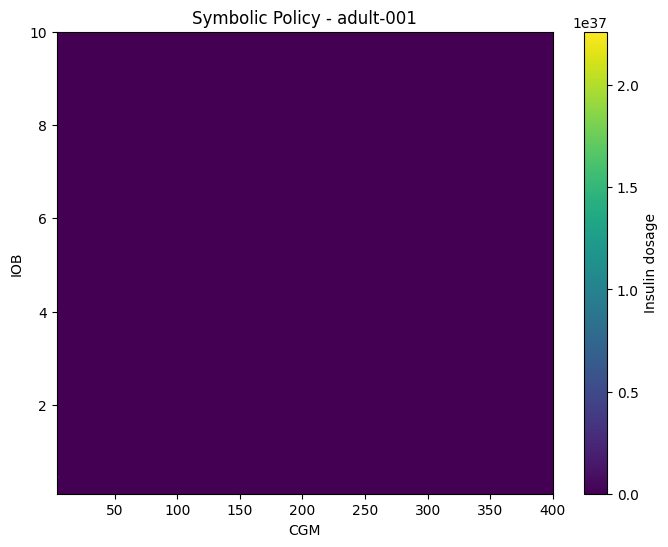

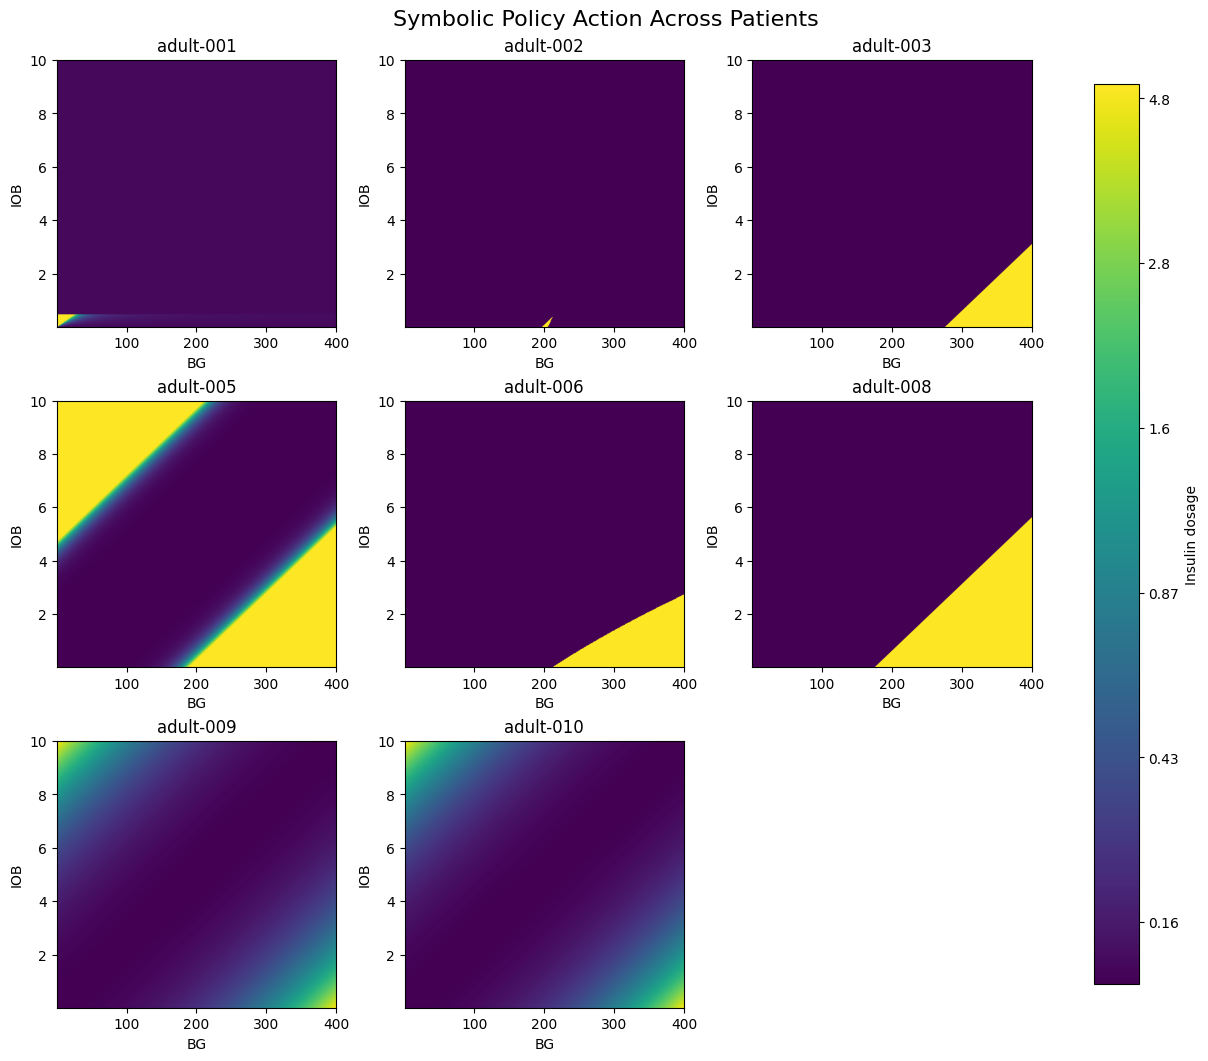

In [14]:
fig, axes = plot_all_patients_pysr_2d(
    policy_df=policy_df,
    x0_range=(0.001, 1.0),
    x1_range=(0.001, 1.0),
    resolution=400,
    n_cols=3,
    title="Symbolic Policy Action Across Patients", 
    shared_colorbar=True, 
    clip_output=(0,5),
    color_transform="log1p",
    color_transform_scale=0.25,
    colorbar_label="Insulin dosage",
)

%matplotlib inline
plt.show()

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import math
from stable_baselines3 import PPO


def compute_grid(
    model,
    x0_range,
    x1_range,
    resolution=300,
    obs_dim=2,
    x0_index=0,
    x1_index=1,
    fixed_obs=None,
    deterministic=True,
    action_index=0,
    transform_fn=None,
    clip_output=None,
):
    """
    Computeaction values over a 2D grid.

    Parameters
    ----------
    model:
        Loaded model.
    x0_range, x1_range:
        Ranges for the two varied input dimensions.
    resolution:
        Grid resolution.
    obs_dim:
        Full observation dimension expected by PPO.
    x0_index, x1_index:
        Which observation dimensions should be varied.
    fixed_obs:
        Optional base observation. Shape: (obs_dim,).
        If None, zeros are used.
    deterministic:
        Whether to use deterministic PPO actions.
    action_index:
        Which action dimension to plot, if action is multidimensional.
    transform_fn:
        Optional transformation applied to PPO output before plotting.
    clip_output:
        Optional tuple, e.g. (0, 5).
    """

    x0 = np.linspace(x0_range[0], x0_range[1], resolution)
    x1 = np.linspace(x1_range[0], x1_range[1], resolution)

    X0, X1 = np.meshgrid(x0, x1)

    if fixed_obs is None:
        base_obs = np.zeros(obs_dim, dtype=np.float32)
    else:
        base_obs = np.asarray(fixed_obs, dtype=np.float32)
        obs_dim = len(base_obs)

    X = np.tile(base_obs, (X0.size, 1))
    X[:, x0_index] = X0.ravel()
    X[:, x1_index] = X1.ravel()

    actions, _ = model.predict(X, deterministic=deterministic)

    actions = np.asarray(actions)

    if actions.ndim == 1:
        Z = actions
    else:
        Z = actions[:, action_index]

    Z = np.asarray(Z, dtype=float).reshape(X0.shape)

    if transform_fn is not None:
        Z = transform_fn(Z)

    if clip_output is not None:
        Z = np.clip(Z, clip_output[0], clip_output[1])

    invalid_mask = ~np.isfinite(Z)
    if invalid_mask.any():
        print(f"Warning: {invalid_mask.sum()} / {Z.size} PPO outputs are NaN or inf.")
        Z = np.ma.masked_invalid(Z)

    return X0, X1, Z

import numpy as np
import matplotlib.pyplot as plt


def plot_grid_figure(
    model,
    x0_range,
    x1_range,
    resolution=300,
    obs_dim=2,
    x0_index=0,
    x1_index=1,
    fixed_obs=None,
    deterministic=True,
    action_index=0,
    transform_fn=None,
    clip_output=None,
    *,
    title=None,
    xlabel=None,
    ylabel=None,
    cbar_label="Action value",
    cmap="viridis",
    levels=50,
    figsize=(7, 6),
    contour_lines=False,
    line_levels=12,
    vmin=None,
    vmax=None,
    save_path=None,
    show=True,
):
    """
    Compute and plot action values over a 2D observation grid as a single figure.

    Parameters
    ----------
    model:
        Loaded model with a Stable-Baselines-style predict method.
    x0_range, x1_range:
        Ranges for the two varied input dimensions.
    resolution:
        Grid resolution.
    obs_dim:
        Full observation dimension expected by the model.
    x0_index, x1_index:
        Which observation dimensions should be varied.
    fixed_obs:
        Optional base observation. Shape: (obs_dim,).
        If None, zeros are used.
    deterministic:
        Whether to use deterministic actions.
    action_index:
        Which action dimension to plot, if action is multidimensional.
    transform_fn:
        Optional transformation applied to model output before plotting.
    clip_output:
        Optional tuple, e.g. (0, 5).

    Figure parameters
    -----------------
    title:
        Figure title.
    xlabel, ylabel:
        Axis labels. Defaults to observation indices.
    cbar_label:
        Colorbar label.
    cmap:
        Matplotlib colormap.
    levels:
        Number of filled contour levels.
    figsize:
        Figure size.
    contour_lines:
        Whether to overlay black contour lines.
    line_levels:
        Number of contour line levels.
    vmin, vmax:
        Optional color scale limits.
    save_path:
        Optional path to save figure.
    show:
        Whether to call plt.show().

    Returns
    -------
    fig, ax, contour
    """

    X0, X1, Z = compute_grid(
        model=model,
        x0_range=x0_range,
        x1_range=x1_range,
        resolution=resolution,
        obs_dim=obs_dim,
        x0_index=x0_index,
        x1_index=x1_index,
        fixed_obs=fixed_obs,
        deterministic=deterministic,
        action_index=action_index,
        transform_fn=transform_fn,
        clip_output=clip_output,
    )

    fig, ax = plt.subplots(figsize=figsize)

    contour = ax.contourf(
        X0,
        X1,
        Z,
        levels=levels,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    if contour_lines:
        lines = ax.contour(
            X0,
            X1,
            Z,
            levels=line_levels,
            colors="black",
            linewidths=0.5,
            alpha=0.5,
        )
        ax.clabel(lines, inline=True, fontsize=8)

    cbar = fig.colorbar(contour, ax=ax)
    cbar.set_label(cbar_label)

    ax.set_xlabel(xlabel or f"Observation {x0_index}")
    ax.set_ylabel(ylabel or f"Observation {x1_index}")

    if title is not None:
        ax.set_title(title)

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    return fig, ax, contour

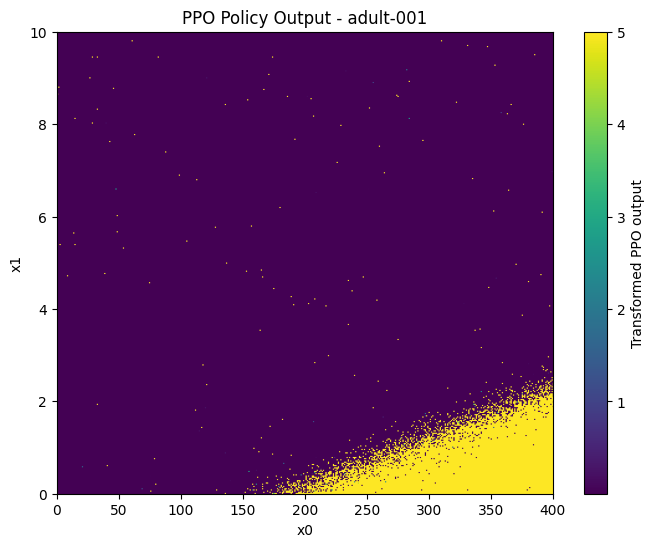

In [16]:
model = PPO.load(
    "./closed_benchmark/positive/adult-002/models/ppo_simglucose_2400000_steps.zip"
)

X0, X1, Z = compute_grid(
    model=model,
    x0_range=(0, 1.0),
    x1_range=(0, 1.0),
    resolution=400,
    obs_dim=2,        # change this if PPO expects more than x0 and x1
    x0_index=0,
    x1_index=1,
    deterministic=False,
    transform_fn=lambda z: 5 * np.exp(4.0 * (z - 1)),
)

plt.figure(figsize=(8, 6))
im = plt.imshow(
    Z,
    extent=[0 * 400, 1.0 * 400, 0 * 10, 1.0 * 10],
    origin="lower",
    aspect="auto",
)
plt.colorbar(im, label="Transformed PPO output")
plt.xlabel("x0")
plt.ylabel("x1")
plt.title("PPO Policy Output - adult-001")
plt.show()

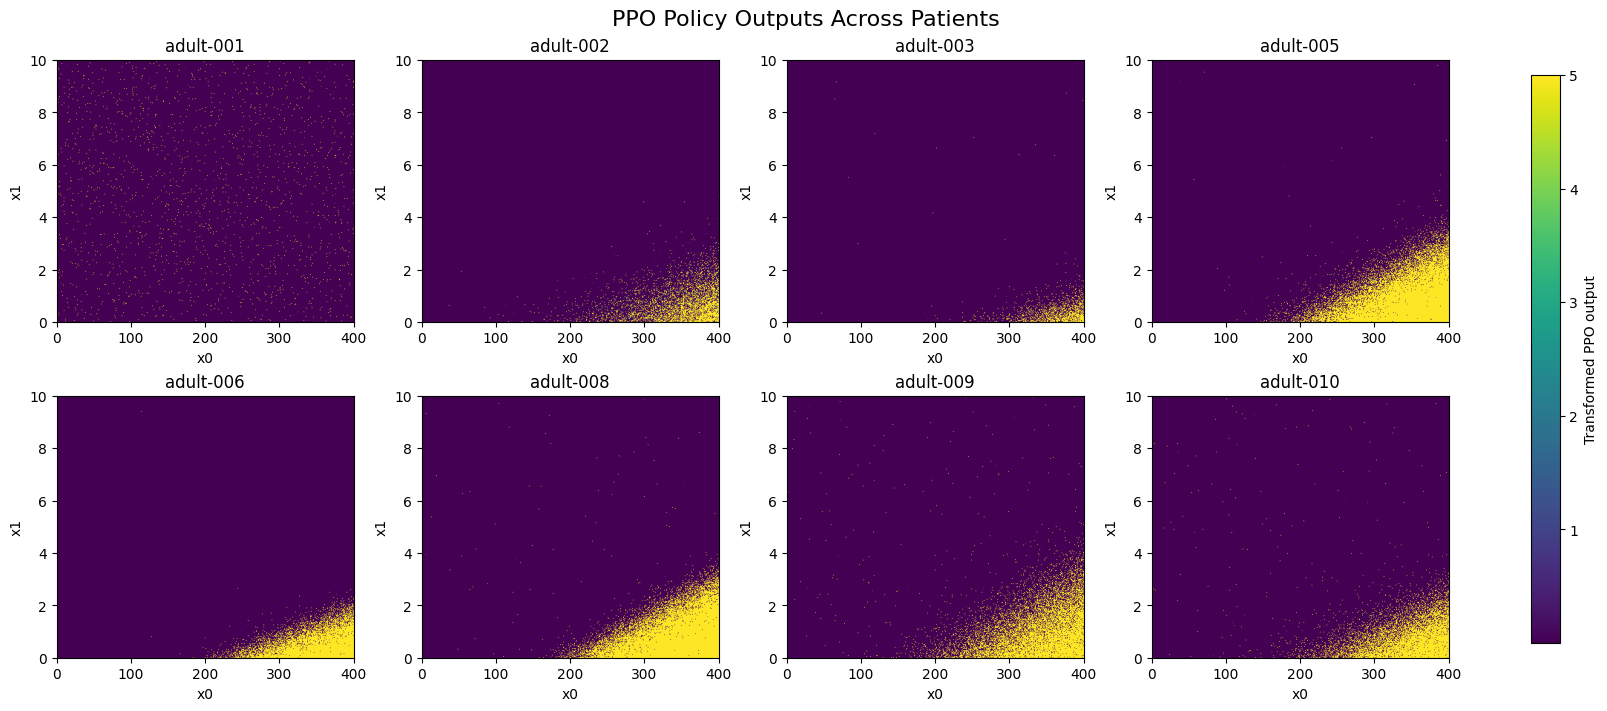

(<Figure size 1600x700 with 9 Axes>,
 array([[<Axes: title={'center': 'adult-001'}, xlabel='x0', ylabel='x1'>,
         <Axes: title={'center': 'adult-002'}, xlabel='x0', ylabel='x1'>,
         <Axes: title={'center': 'adult-003'}, xlabel='x0', ylabel='x1'>,
         <Axes: title={'center': 'adult-005'}, xlabel='x0', ylabel='x1'>],
        [<Axes: title={'center': 'adult-006'}, xlabel='x0', ylabel='x1'>,
         <Axes: title={'center': 'adult-008'}, xlabel='x0', ylabel='x1'>,
         <Axes: title={'center': 'adult-009'}, xlabel='x0', ylabel='x1'>,
         <Axes: title={'center': 'adult-010'}, xlabel='x0', ylabel='x1'>]],
       dtype=object))

In [17]:
def plot_all_patients_ppo_2d(
    policy_df,
    model_path_template="./closed_benchmark/positive/{patient}/models/best/best_model.zip",
    
    x0_range=(0, 1.0),
    x1_range=(0, 1.0),
    resolution=300,
    obs_dim=2,
    x0_index=0,
    x1_index=1,
    fixed_obs=None,
    deterministic=True,
    action_index=0,
    transform_fn=lambda z: 5 * np.exp(4.0 * (z - 1)),
    clip_output=None,
    n_cols=4,
    figsize_per_plot=(4, 3.5),
    title="PPO policy outputs across patients",
    colorbar_label="Transformed PPO output",
    scale_x0=400,
    scale_x1=10,
):
    patients = list(policy_df.index)
    n_patients = len(patients)

    n_cols = min(n_cols, n_patients)
    n_rows = math.ceil(n_patients / n_cols)

    grids = []
    all_values = []

    for patient in patients:
        if "model_path" in policy_df.columns:
            model_path = policy_df.loc[patient, "model_path"]
        else:
            model_path = model_path_template.format(patient=patient)

        model = PPO.load(model_path)

        _, _, Z = compute_grid(
            model=model,
            x0_range=x0_range,
            x1_range=x1_range,
            resolution=resolution,
            obs_dim=obs_dim,
            x0_index=x0_index,
            x1_index=x1_index,
            fixed_obs=fixed_obs,
            deterministic=deterministic,
            action_index=action_index,
            transform_fn=transform_fn,
            clip_output=clip_output,
        )

        grids.append((patient, Z))

        if np.ma.isMaskedArray(Z):
            values = Z.compressed()
        else:
            values = Z[np.isfinite(Z)]

        all_values.append(values)

    all_values = np.concatenate(all_values)
    vmin = np.nanmin(all_values)
    vmax = np.nanmax(all_values)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_plot[0] * n_cols, figsize_per_plot[1] * n_rows),
        squeeze=False,
        constrained_layout=True,
    )

    extent = [
        x0_range[0] * scale_x0,
        x0_range[1] * scale_x0,
        x1_range[0] * scale_x1,
        x1_range[1] * scale_x1,
    ]

    im = None

    for ax, (patient, Z) in zip(axes.flat, grids):
        im = ax.imshow(
            Z,
            extent=extent,
            origin="lower",
            aspect="auto",
            vmin=vmin,
            vmax=vmax,
        )

        ax.set_title(str(patient))
        ax.set_xlabel("x0")
        ax.set_ylabel("x1")

    for ax in axes.flat[len(grids):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=16)

    cbar = fig.colorbar(
        im,
        ax=axes,
        orientation="vertical",
        shrink=0.95,
    )
    cbar.set_label(colorbar_label)

    plt.show()

    return fig, axes

plot_all_patients_ppo_2d(
    policy_df=policy_df,
    x0_range=(0.0, 1.0),
    x1_range=(0.0, 1.),
    resolution=400,
    obs_dim=2,
    x0_index=0,
    x1_index=1,
    deterministic=False,
    n_cols=4,
    title="PPO Policy Outputs Across Patients",
)

# Sample trajectory

In [18]:
def _predict_action(policy, obs, deterministic=True):
    """
    Works with SB3 PPO and SB3-compatible symbolic policies.
    Handles both:
        action, state = policy.predict(...)
    and:
        action = policy.predict(...)
    """
    out = policy.predict(obs, deterministic=deterministic)

    if isinstance(out, tuple):
        action = out[0]
    else:
        action = out

    return action


def _format_action_for_vecenv(action):
    """
    Ensures action has shape compatible with DummyVecEnv / VecMonitor:
        (n_envs, action_dim)
    For your case n_envs = 1.
    """
    action = np.asarray(action, dtype=np.float32)

    if action.ndim == 0:
        action = action.reshape(1, 1)
    elif action.ndim == 1:
        action = action.reshape(1, -1)

    return action


def collect_policy_trajectories(
    policy,
    env,
    n_trajectories=10,
    expected_steps=480,
    deterministic=True,
    x0_index=0,
    x1_index=1,
    clip_actions=False,
):
    """
    Collect trajectories from either a PPO model or PySRPolicy.

    Parameters
    ----------
    policy:
        SB3 PPO model or SB3-compatible PySRPolicy.
    env:
        VecEnv, e.g. VecMonitor(DummyVecEnv(...)).
    n_trajectories:
        Number of episodes to collect.
    expected_steps:
        Episode length expected if not terminated early.
    deterministic:
        Whether to use deterministic policy actions.
    x0_index, x1_index:
        Observation dimensions to record for plotting.
    clip_actions:
        If True, clips actions to env.action_space bounds.

    Returns
    -------
    trajectories:
        List of dicts, one per episode.
    summary_df:
        DataFrame with episode-level summary.
    """

    trajectories = []
    summaries = []

    action_space = getattr(env, "action_space", None)

    for ep in range(n_trajectories):
        obs = env.reset()

        obs_list = []
        action_list = []
        reward_list = []
        info_list = []

        done = False
        step_count = 0

        while step_count < expected_steps:
            # Store current observation before action
            obs_single = np.asarray(obs[0]).copy()
            obs_list.append(obs_single)

            action = _predict_action(policy, obs, deterministic=deterministic)
            action = _format_action_for_vecenv(action)

            if clip_actions and action_space is not None:
                action = np.clip(action, action_space.low, action_space.high)

            next_obs, reward, dones, infos = env.step(action)

            action_list.append(np.asarray(action[0]).copy())
            reward_list.append(float(reward[0]))
            info_list.append(infos[0])

            step_count += 1
            done = bool(dones[0])

            obs = next_obs

            if done:
                break

        obs_array = np.asarray(obs_list)
        action_array = np.asarray(action_list)
        reward_array = np.asarray(reward_list)

        # Episode is considered early terminated if it stopped before 480 steps.
        early_terminated = bool(done and step_count < expected_steps)
        completed_expected_length = bool(step_count >= expected_steps)

        # SB3 VecEnv sometimes stores timeout info here
        last_info = info_list[-1] if len(info_list) > 0 else {}
        time_limit_truncated = bool(last_info.get("TimeLimit.truncated", False))

        traj = {
            "episode": ep,
            "obs": obs_array,
            "actions": action_array,
            "rewards": reward_array,
            "infos": info_list,
            "x0": obs_array[:, x0_index],
            "x1": obs_array[:, x1_index],
            "steps": step_count,
            "done": bool(done),
            "early_terminated": early_terminated,
            "completed_expected_length": completed_expected_length,
            "time_limit_truncated": time_limit_truncated,
            "total_reward": float(np.sum(reward_array)),
        }

        trajectories.append(traj)

        summaries.append({
            "episode": ep,
            "steps": step_count,
            "done": bool(done),
            "early_terminated": early_terminated,
            "completed_expected_length": completed_expected_length,
            "time_limit_truncated": time_limit_truncated,
            "total_reward": float(np.sum(reward_array)),
            "mean_reward": float(np.mean(reward_array)) if len(reward_array) else np.nan,
        })

    summary_df = pd.DataFrame(summaries)

    return trajectories, summary_df

In [19]:
# Evaluation using model Adult10 - 27 
from stable_baselines3.ppo import PPO

patient = "adult-002"



ppo_model = PPO.load(
    f"./closed_benchmark/positive/{patient}/models/best/best_model.zip"
)

symbolic_policy = PySRPolicy.load(f"./distil_closed_safe_diagnostic_positive_remapped/positive/adult-002/best_student_policy.joblib")
symbolic_policy.action_transform = lambda x: x
patient = "adult#002"

meals = [
    (7 * 60, 45.0),
    (12 * 60, 70.0),
    (16 * 60, 15.0),
    (18 * 60, 80.0),
    (23 * 60, 10.0),
]

eval_env = DummyVecEnv([
    make_env_fn(
        env_id="simglucose-spid-eval-v0",
        patient=patient,
        meals=meals,
        max_episode_steps=480,
        seed=None,
        scenario_mode="semi_random_hb",
        time_std_multiplier=0.5,
        include_snacks=True,
        reward_type="positive",
        warning_window_min=20,
        insulin_tau_min=55,
        sample_time_min=3,
        max_insulin_action=5,
        amount_noise_std_fraction=0.3,
        actual_time_noise_clip_min=30.0,
        actual_time_noise_std_min=60.0,
        use_bb_warmup=True,
        shield_bg_threshold=10
        
    )
])

eval_env = VecMonitor(eval_env)


ppo_trajectories, ppo_summary = collect_policy_trajectories(
    policy=ppo_model,
    env=eval_env,
    n_trajectories=10,
    expected_steps=480,
    deterministic=True,
    x0_index=0,
    x1_index=1,
)

symbolic_trajectories, symbolic_summary = collect_policy_trajectories(
    policy=symbolic_policy,   # your PySRPolicy / SB3-compatible symbolic model
    env=eval_env,
    n_trajectories=10,
    expected_steps=480,
    deterministic=True,
    x0_index=0,
    x1_index=1,
)

print(symbolic_summary)

ppo_summary

KeyboardInterrupt: 

In [ ]:
def overlay_trajectories_on_axis(
    ax,
    trajectories,
    label="trajectory",
    scale_x0=400,
    scale_x1=10,
    alpha=0.85,
    linewidth=1.5,
    show_start_end=True,
):
    """
    Overlay sampled trajectories on an existing grid axis.

    Solid lines = completed full episode.
    Dashed lines = terminated before expected_steps.
    """

    added_completed_label = False
    added_terminated_label = False

    for traj in trajectories:
        x = traj["x0"] * scale_x0
        y = traj["x1"] * scale_x1

        early = traj["early_terminated"]

        if early:
            linestyle = "--"
            line_label = f"{label} early terminated" if not added_terminated_label else None
            added_terminated_label = True
        else:
            linestyle = "-"
            line_label = f"{label} completed" if not added_completed_label else None
            added_completed_label = True

        ax.plot(
            x,
            y,
            linestyle=linestyle,
            linewidth=linewidth,
            alpha=alpha,
            label=line_label,
        )

        if show_start_end and len(x) > 0:
            ax.scatter(x[0], y[0], marker="o", s=20, alpha=alpha)
            ax.scatter(x[-1], y[-1], marker="x", s=30, alpha=alpha)

    return ax

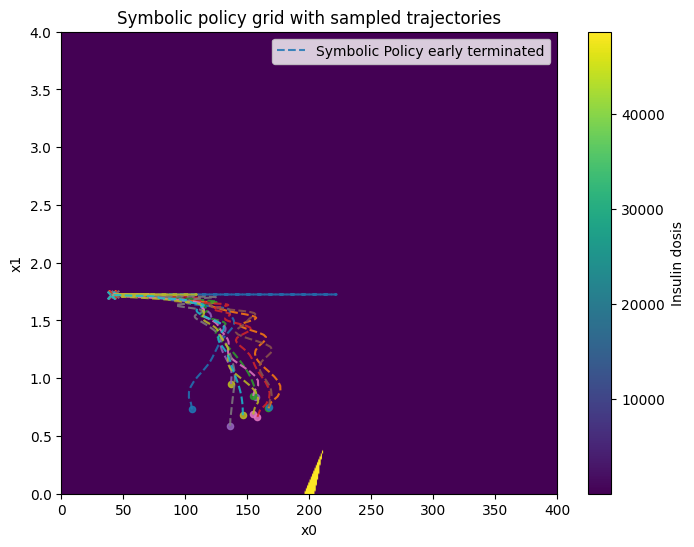

In [ ]:
X0, X1, Z = compute_grid(
    model=symbolic_policy,
    x0_range=(0, 1.0),
    x1_range=(0, 1.0),
    resolution=400,
    obs_dim=eval_env.observation_space.shape[0],
    x0_index=0,
    x1_index=1,
    deterministic=True,
    transform_fn=lambda z: 5 * np.exp(4.0 * (z - 1)),
)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    Z,
    extent=[0, 400, 0, 10],
    origin="lower",
    aspect="auto",
)

fig.colorbar(im, ax=ax, label="Insulin dosis")

overlay_trajectories_on_axis(
    ax,
    symbolic_trajectories,
    label="Symbolic Policy",
    scale_x0=400,
    scale_x1=10,
)

ax.set_xlim((0, 400))
ax.set_ylim((0, 4))

ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.set_title("Symbolic policy grid with sampled trajectories")
ax.legend()
plt.show()

In [ ]:
X0, X1, Z = compute_ppo_grid(
    model=ppo_model,
    x0_range=(0, 1.0),
    x1_range=(0, 1.0),
    resolution=400,
    obs_dim=eval_env.observation_space.shape[0],
    x0_index=0,
    x1_index=1,
    deterministic=True,
    transform_fn=lambda z: 5 * np.exp(4.0 * (z - 1)),
)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    Z,
    extent=[0, 400, 0, 10],
    origin="lower",
    aspect="auto",
)

fig.colorbar(im, ax=ax, label="Insulin dosis")

overlay_trajectories_on_axis(
    ax,
    ppo_trajectories,
    label="Symbolic Policy",
    scale_x0=400,
    scale_x1=10,
)

ax.set_xlim((0, 400))
ax.set_ylim((0, 6))

ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.set_title("PPO policy grid with sampled trajectories")
ax.legend()
plt.show()

NameError: name 'compute_ppo_grid' is not defined

In [ ]:
os.getcwd()

'/faststorage/project/GGSpeciale/GGSpeciale/simglucose_singlepatient'

## Training Curves

Reward curves with development of mean reward, TIR and critical failure, for individual pateient, or across entire cohort

In [5]:

while not os.getcwd().endswith("GGSpeciale"):
    os.chdir("..")
os.chdir("Simglucose_suite/")
from evaluate import evaluate_insulin_policy
from train_closed import make_env_fn

os.getcwd()

folder_path = Path("./models/fine_grained/closed_hist_optuna_optimal_2/clarke_risk")
patient_name = "adult-001"

metrics_log = folder_path / patient_name / "insulin_eval/eval_log/metrics_log.csv"
print(metrics_log)

metrics = pd.read_csv(metrics_log)
metrics.head()

models/fine_grained/closed_hist_optuna_optimal_2/clarke_risk/adult-001/insulin_eval/eval_log/metrics_log.csv


,eval_index,TBR_II_mean,TBR_II_std,TBR_II_tol90_low,TBR_II_tol90_high,TBR_II_tol90_width,TIR_II_mean,TIR_II_std,TIR_II_tol90_low,TIR_II_tol90_high,...,max_BG_tol90_width,critical_failure_rate,survivors,num_timesteps,mean_reward,std_reward,reward_tol90_low,reward_tol90_high,reward_tol90_width,n_eval_episodes
0,0,2.031250,2.154177,0.0,5.000000,5.000000,91.145833,12.405313,72.708333,98.958333,...,120.604362,96.0,4,200000,167.421560,99.555150,50.712505,381.167165,330.454660,100
1,1,0.036765,0.151585,0.0,0.625000,0.625000,87.365196,11.808095,60.833333,100.000000,...,167.282412,83.0,17,210000,197.892213,116.695846,50.760127,425.555170,374.795043,100
2,2,1.412037,1.934187,0.0,4.791667,4.791667,91.875000,7.644726,76.458333,100.000000,...,162.367302,91.0,9,230000,180.380890,108.554313,49.537639,394.444669,344.907029,100
3,3,0.354918,1.153011,0.0,4.493243,4.493243,75.737425,21.629979,36.441441,100.000000,...,222.299998,63.0,37,240000,232.147704,116.803382,50.024523,428.750664,378.726140,100
4,4,1.201923,3.534703,0.0,16.458333,16.458333,73.766026,18.781263,36.458333,100.000000,...,203.732667,74.0,26,250000,213.905881,97.115004,46.068915,411.379901,365.310986,100


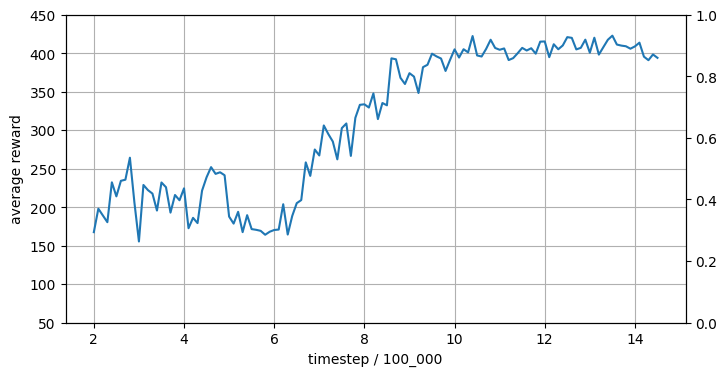

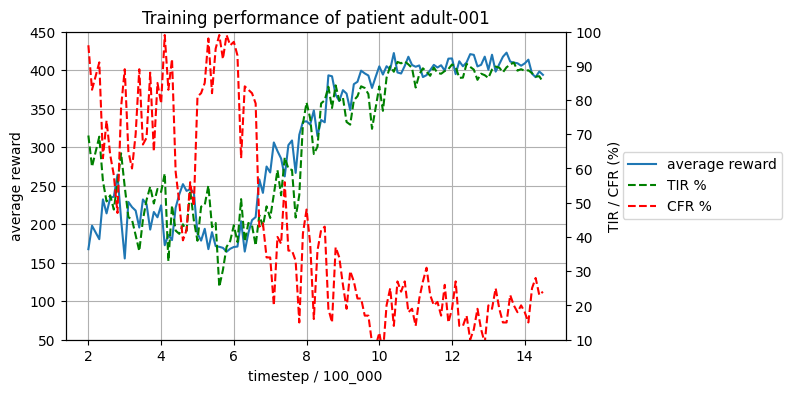

In [7]:
fig, ax1 = plt.subplots(figsize = (8, 4))

x = metrics["num_timesteps"] / 100_000

ax1.plot(x, metrics["mean_reward"], label="average reward")
ax1.set_xlabel("timestep / 100_000")
ax1.set_ylabel("average reward")
ax1.grid()

plt.ylim((50, 450))

ax2 = ax1.twinx()
ax2.plot(x, metrics["TIR_mean"], linestyle="--", label="TIR %", color="green")
ax2.plot(x, metrics["critical_failure_rate"], linestyle="--", label="CFR %", color="red")
ax2.set_ylabel("TIR / CFR (%)")
plt.ylim((10, 100))

plt.title(f"Training performance of patient {patient_name}")

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="center left",
    bbox_to_anchor=(1.1, 0.5)
)

# Make room for legend on the right
fig.subplots_adjust(right=0.75)


%matplotlib inline
plt.show()

In [9]:
# folder_path = Path("./closed_benchmark/positive/")
metrics_log = "insulin_eval/eval_log/metrics_log.csv"

eval_metrics = []
patient_names = []

for folder in folder_path.iterdir():

    if folder.is_dir():        
        file_path = folder / metrics_log

        if file_path.exists():
            patient_names.append(folder.name)
            print(f"loading {folder.name}")

            metric = pd.read_csv(file_path)
            eval_metrics.append(metric)

eval_metrics_df = pd.concat(eval_metrics, keys=patient_names)

eval_metrics_df = eval_metrics_df.sort_index(level=0)


loading adult-001


KeyError: 'TIR'

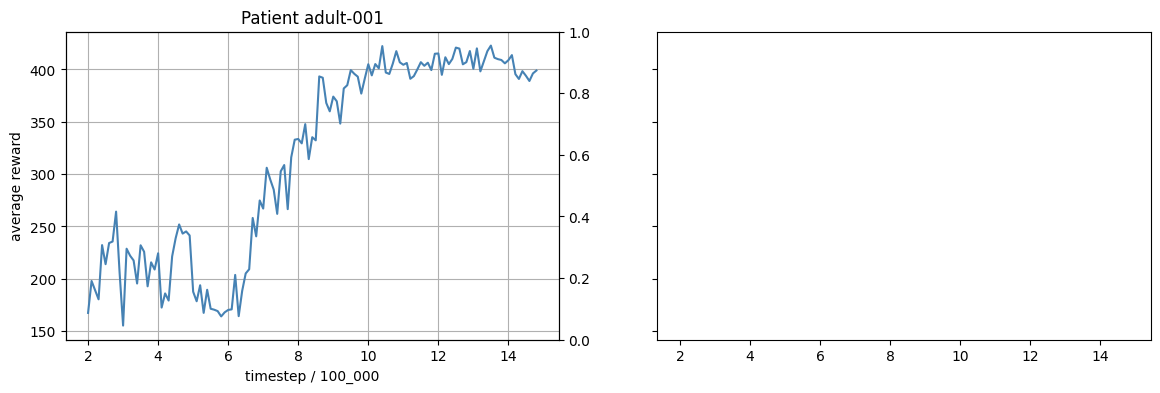

In [10]:
import numpy as np
import matplotlib.pyplot as plt

patient_names = eval_metrics_df.index.get_level_values(0).unique()

n_patients = len(patient_names)
n_cols = 2
n_rows = int(np.ceil(n_patients / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 4 * n_rows),
    sharex=True,
    sharey=True
)

axes = np.array(axes).reshape(-1)

legend_lines = None
legend_labels = None
secondary_axes = []

for i, patient_name in enumerate(patient_names):
    ax1 = axes[i]

    metrics = eval_metrics_df.loc[patient_name]
    x = metrics["num_timesteps"] / 100_000

    line1, = ax1.plot(
        x,
        metrics["mean_reward"],
        label="average reward",
        color="steelblue"
    )

    ax1.set_title(f"Patient {patient_name}")
    ax1.set_xlabel("timestep / 100_000")
    ax1.set_ylabel("average reward")
    ax1.grid()

    ax2 = ax1.twinx()

    if secondary_axes:
        ax2.sharey(secondary_axes[0])

    secondary_axes.append(ax2)

    line2, = ax2.plot(
        x,
        metrics["TIR"],
        linestyle="--",
        label="TIR %",
        color="green"
    )

    line3, = ax2.plot(
        x,
        metrics["critical_failure_rate"],
        linestyle="--",
        label="CFR %",
        color="red"
    )

    ax2.set_ylabel("TIR / CFR (%)")

    if legend_lines is None:
        legend_lines = [line1, line2, line3]
        legend_labels = [line.get_label() for line in legend_lines]

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
fig.legend(
    legend_lines,
    legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),
    ncol=len(legend_labels),
    fontsize=14,          # larger text
    markerscale=1.5,      # larger marker symbols, if any
    handlelength=3,       # longer line samples
    handletextpad=0.8,    # space between line and text
    columnspacing=1.5,    # space between legend entries
    frameon=True,
    fancybox=False,
    shadow=False,
    framealpha=1
)

fig.suptitle("Training performance for Open-Loop model across patients", fontsize=16, y=.98)
        
fig.tight_layout(rect=[0, 0, 1, 0.94])
#fig.savefig("figures/training_performance_closed_loop.png")
plt.show()

# 

## Plot and evaluate policies from training

* Take evaluation folder with multiple models
* Set interval for examining every *n* policy 
* plot reward over timesteps, TIR over timesteps, Critical Failure over timesteps